In [62]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dados/raw/application_train.csv')

print(df.shape)

(307511, 122)


In [63]:
df['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [64]:
(df['DAYS_EMPLOYED'] == 365243).sum()

np.int64(55374)

In [65]:
(df['DAYS_EMPLOYED'] == 365243).mean() * 100

np.float64(18.00716071945394)

Próximo passo
Antes de substituir por NaN, remover ou transformar qualquer coisa, vamos responder uma pergunta:

Os clientes com DAYS_EMPLOYED = 365243 se comportam diferente dos demais?

In [66]:
df.groupby(df['DAYS_EMPLOYED'] == 365243)['TARGET'].mean() * 100

DAYS_EMPLOYED
False    8.659975
True     5.399646
Name: TARGET, dtype: float64

In [67]:
df[['EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3']].isnull().mean() * 100

EXT_SOURCE_1    56.381073
EXT_SOURCE_2     0.214626
EXT_SOURCE_3    19.825307
dtype: float64

#### Clientes sem EXT_SOURCE_1 possuem comportamento de inadimplência diferente?

In [68]:
df.groupby(
    df['EXT_SOURCE_1'].isnull()
)['TARGET'].mean() * 100

EXT_SOURCE_1
False    7.495545
True     8.519535
Name: TARGET, dtype: float64

In [69]:
high_missing = [
    'COMMONAREA_AVG',
    'LIVINGAPARTMENTS_AVG',
    'NONLIVINGAPARTMENTS_AVG'
]

(df[high_missing].isnull().mean() * 100).sort_values(ascending=False)

COMMONAREA_AVG             69.872297
NONLIVINGAPARTMENTS_AVG    69.432963
LIVINGAPARTMENTS_AVG       68.354953
dtype: float64

In [70]:
for col in high_missing:
    print(f"\n{col}")
    print(
        df.groupby(df[col].isnull())['TARGET']
          .mean() * 100
    )


COMMONAREA_AVG
COMMONAREA_AVG
False    6.910174
True     8.574221
Name: TARGET, dtype: float64

LIVINGAPARTMENTS_AVG
LIVINGAPARTMENTS_AVG
False    6.888154
True     8.621354
Name: TARGET, dtype: float64

NONLIVINGAPARTMENTS_AVG
NONLIVINGAPARTMENTS_AVG
False    6.912987
True     8.583512
Name: TARGET, dtype: float64


In [71]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Quantidade de variáveis categóricas: {len(categorical_cols)}')

categorical_cols

Quantidade de variáveis categóricas: 16


C:\Users\Weel_\AppData\Local\Temp\ipykernel_24056\3449407814.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [72]:
for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].value_counts(dropna=False).head(10))


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / s

### ABT V1

In [73]:
abt_features = [
    'TARGET',

    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',

    'DAYS_BIRTH',
    'DAYS_EMPLOYED',

    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',

    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',

    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',

    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',

    'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',

    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

abt_v1 = df[abt_features].copy()

print(abt_v1.shape)

(307511, 28)


In [74]:
abt_v1.isnull().mean().sort_values(ascending=False) * 100

EXT_SOURCE_1                   56.381073
OCCUPATION_TYPE                31.345545
EXT_SOURCE_3                   19.825307
AMT_REQ_CREDIT_BUREAU_YEAR     13.501631
AMT_REQ_CREDIT_BUREAU_DAY      13.501631
AMT_REQ_CREDIT_BUREAU_QRT      13.501631
AMT_REQ_CREDIT_BUREAU_MON      13.501631
AMT_REQ_CREDIT_BUREAU_WEEK     13.501631
EXT_SOURCE_2                    0.214626
AMT_GOODS_PRICE                 0.090403
AMT_ANNUITY                     0.003902
CNT_FAM_MEMBERS                 0.000650
NAME_INCOME_TYPE                0.000000
FLAG_OWN_REALTY                 0.000000
FLAG_OWN_CAR                    0.000000
CNT_CHILDREN                    0.000000
DAYS_BIRTH                      0.000000
DAYS_EMPLOYED                   0.000000
AMT_INCOME_TOTAL                0.000000
AMT_CREDIT                      0.000000
TARGET                          0.000000
NAME_EDUCATION_TYPE             0.000000
NAME_FAMILY_STATUS              0.000000
NAME_HOUSING_TYPE               0.000000
ORGANIZATION_TYP

In [75]:
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df[bureau_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
AMT_REQ_CREDIT_BUREAU_YEAR,265992.0,1.899974,1.869295,0.0,0.0,1.0,3.0,25.0


In [76]:
abt_v1_clean = abt_v1.copy()

In [77]:
abt_v1_clean.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS,FLAG_OWN_CAR,...,EXT_SOURCE_2,EXT_SOURCE_3,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,202500.0,406597.5,24700.5,351000.0,-9461,-637,0,1.0,N,...,0.262949,0.139376,0.018801,2,2,0.0,0.0,0.0,0.0,1.0
1,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,0,2.0,N,...,0.622246,NaN,0.003541,1,1,0.0,0.0,0.0,0.0,0.0
2,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,0,1.0,Y,...,0.555912,0.729567,0.010032,2,2,0.0,0.0,0.0,0.0,0.0
3,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,0,2.0,N,...,0.650442,NaN,0.008019,2,2,NaN,NaN,NaN,NaN,NaN
4,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,0,1.0,N,...,0.322738,NaN,0.028663,2,2,0.0,0.0,0.0,0.0,0.0


In [78]:

abt_v1_clean['OCCUPATION_TYPE'] = (
    abt_v1_clean['OCCUPATION_TYPE']
    .fillna('UNKNOWN')
)


In [79]:
abt_v1_clean

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS,FLAG_OWN_CAR,...,EXT_SOURCE_2,EXT_SOURCE_3,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,202500.0,406597.5,24700.5,351000.0,-9461,-637,0,1.0,N,...,0.262949,0.139376,0.018801,2,2,0.0,0.0,0.0,0.0,1.0
1,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,0,2.0,N,...,0.622246,NaN,0.003541,1,1,0.0,0.0,0.0,0.0,0.0
2,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,0,1.0,Y,...,0.555912,0.729567,0.010032,2,2,0.0,0.0,0.0,0.0,0.0
3,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,0,2.0,N,...,0.650442,NaN,0.008019,2,2,NaN,NaN,NaN,NaN,NaN
4,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,0,1.0,N,...,0.322738,NaN,0.028663,2,2,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,157500.0,254700.0,27558.0,225000.0,-9327,-236,0,1.0,N,...,0.681632,NaN,0.032561,1,1,NaN,NaN,NaN,NaN,NaN
307507,0,72000.0,269550.0,12001.5,225000.0,-20775,365243,0,1.0,N,...,0.115992,NaN,0.025164,2,2,NaN,NaN,NaN,NaN,NaN
307508,0,153000.0,677664.0,29979.0,585000.0,-14966,-7921,0,1.0,N,...,0.535722,0.218859,0.005002,3,3,0.0,0.0,1.0,0.0,1.0
307509,1,171000.0,370107.0,20205.0,319500.0,-11961,-4786,0,2.0,N,...,0.514163,0.661024,0.005313,2,2,0.0,0.0,0.0,0.0,0.0


In [80]:
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

abt_v1_clean[bureau_cols] = (
    abt_v1_clean[bureau_cols]
    .fillna(0)
)

Criar flags:

In [81]:
abt_v1_clean['EXT_SOURCE_1_MISSING'] = (
    abt_v1_clean['EXT_SOURCE_1']
    .isnull()
    .astype(int)
)

abt_v1_clean['EXT_SOURCE_3_MISSING'] = (
    abt_v1_clean['EXT_SOURCE_3']
    .isnull()
    .astype(int)
)

In [82]:
abt_v1_clean.isnull().mean().sort_values(ascending=False) * 100

EXT_SOURCE_1                   56.381073
EXT_SOURCE_3                   19.825307
EXT_SOURCE_2                    0.214626
AMT_GOODS_PRICE                 0.090403
AMT_ANNUITY                     0.003902
CNT_FAM_MEMBERS                 0.000650
DAYS_BIRTH                      0.000000
DAYS_EMPLOYED                   0.000000
CNT_CHILDREN                    0.000000
FLAG_OWN_CAR                    0.000000
FLAG_OWN_REALTY                 0.000000
AMT_INCOME_TOTAL                0.000000
AMT_CREDIT                      0.000000
TARGET                          0.000000
NAME_FAMILY_STATUS              0.000000
NAME_EDUCATION_TYPE             0.000000
NAME_INCOME_TYPE                0.000000
NAME_HOUSING_TYPE               0.000000
ORGANIZATION_TYPE               0.000000
OCCUPATION_TYPE                 0.000000
REGION_POPULATION_RELATIVE      0.000000
REGION_RATING_CLIENT            0.000000
REGION_RATING_CLIENT_W_CITY     0.000000
AMT_REQ_CREDIT_BUREAU_DAY       0.000000
AMT_REQ_CREDIT_B

In [83]:
numeric_cols = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'CNT_FAM_MEMBERS'
]

for col in numeric_cols:
    abt_v1_clean[col] = (
        abt_v1_clean[col]
        .fillna(abt_v1_clean[col].median())
    )

In [84]:
abt_v1_clean.isnull().sum().sum()

np.int64(0)

In [85]:
abt_v1_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TARGET                       307511 non-null  int64  
 1   AMT_INCOME_TOTAL             307511 non-null  float64
 2   AMT_CREDIT                   307511 non-null  float64
 3   AMT_ANNUITY                  307511 non-null  float64
 4   AMT_GOODS_PRICE              307511 non-null  float64
 5   DAYS_BIRTH                   307511 non-null  int64  
 6   DAYS_EMPLOYED                307511 non-null  int64  
 7   CNT_CHILDREN                 307511 non-null  int64  
 8   CNT_FAM_MEMBERS              307511 non-null  float64
 9   FLAG_OWN_CAR                 307511 non-null  str    
 10  FLAG_OWN_REALTY              307511 non-null  str    
 11  NAME_INCOME_TYPE             307511 non-null  str    
 12  NAME_EDUCATION_TYPE          307511 non-null  str    
 13  NAME_FAMIL

In [86]:
abt_v1_clean.select_dtypes(include='object').columns.tolist()

C:\Users\Weel_\AppData\Local\Temp\ipykernel_24056\381248417.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  abt_v1_clean.select_dtypes(include='object').columns.tolist()


['FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE']

In [87]:
for col in abt_v1_clean.select_dtypes(include='object').columns:
    print(f'{col}: {abt_v1_clean[col].nunique()}')

FLAG_OWN_CAR: 2


C:\Users\Weel_\AppData\Local\Temp\ipykernel_24056\1123085347.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in abt_v1_clean.select_dtypes(include='object').columns:


FLAG_OWN_REALTY: 2
NAME_INCOME_TYPE: 8
NAME_EDUCATION_TYPE: 5
NAME_FAMILY_STATUS: 6
NAME_HOUSING_TYPE: 6
OCCUPATION_TYPE: 19
ORGANIZATION_TYPE: 58


In [88]:
abt_v1_clean.shape

(307511, 30)

In [89]:
abt_v1_clean.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS,FLAG_OWN_CAR,...,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_MISSING,EXT_SOURCE_3_MISSING
0,1,202500.0,406597.5,24700.5,351000.0,-9461,-637,0,1.0,N,...,0.018801,2,2,0.0,0.0,0.0,0.0,1.0,0,0
1,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,0,2.0,N,...,0.003541,1,1,0.0,0.0,0.0,0.0,0.0,0,1
2,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,0,1.0,Y,...,0.010032,2,2,0.0,0.0,0.0,0.0,0.0,1,0
3,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,0,2.0,N,...,0.008019,2,2,0.0,0.0,0.0,0.0,0.0,1,1
4,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,0,1.0,N,...,0.028663,2,2,0.0,0.0,0.0,0.0,0.0,1,1


## Pre Modeling 

In [90]:
X = abt_v1_clean.drop(columns=['TARGET'])
y = abt_v1_clean['TARGET']

print(X.shape)
print(y.shape)

(307511, 29)
(307511,)


In [91]:
X.select_dtypes(include='object').columns.tolist()

C:\Users\Weel_\AppData\Local\Temp\ipykernel_24056\318371232.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include='object').columns.tolist()


['FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE']

In [92]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

In [93]:
print(X_encoded.shape)


(307511, 119)


In [94]:
X_encoded.head()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA
0,202500.0,406597.5,24700.5,351000.0,-9461,-637,0,1.0,0.083037,0.262949,...,False,False,False,False,False,False,False,False,False,False
1,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,0,2.0,0.311267,0.622246,...,False,False,False,False,False,False,False,False,False,False
2,67500.0,135000.0,6750.0,135000.0,-19046,-225,0,1.0,0.505998,0.555912,...,False,False,False,False,False,False,False,False,False,False
3,135000.0,312682.5,29686.5,297000.0,-19005,-3039,0,2.0,0.505998,0.650442,...,False,False,False,False,False,False,False,False,False,False
4,121500.0,513000.0,21865.5,513000.0,-19932,-3038,0,1.0,0.505998,0.322738,...,False,False,False,False,False,False,False,False,False,False


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(246008, 119)
(61503, 119)
(246008,)
(61503,)


In [96]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train, y_train)

C:\Users\Weel_\OneDrive\Área de Trabalho\proscore-creditguard-ai\creditguard-env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [97]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.9192884899923581
Precision: 0.6666666666666666
Recall   : 0.0004028197381671702
F1-Score : 0.0008051529790660225
ROC-AUC  : 0.6926951855888029


In [99]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[56537,     1],
       [ 4963,     2]])

In [100]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.67      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.79      0.50      0.48     61503
weighted avg       0.90      0.92      0.88     61503



In [101]:
confusion_matrix(y_test, y_pred)

classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.92      1.00      0.96     56538\n           1       0.67      0.00      0.00      4965\n\n    accuracy                           0.92     61503\n   macro avg       0.79      0.50      0.48     61503\nweighted avg       0.90      0.92      0.88     61503\n'

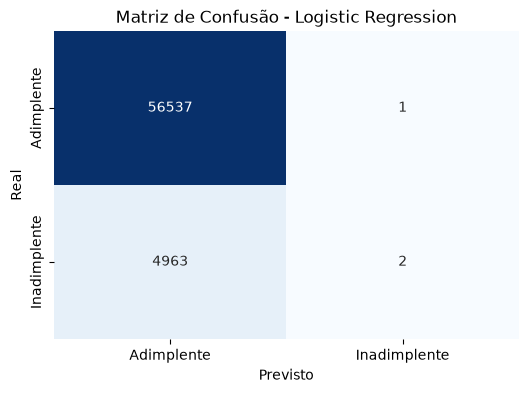

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Adimplente', 'Inadimplente'],
    yticklabels=['Adimplente', 'Inadimplente']
)

plt.title('Matriz de Confusão - Logistic Regression')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

In [103]:

from sklearn.linear_model import LogisticRegression

modelo_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

modelo_balanced.fit(X_train, y_train)


C:\Users\Weel_\OneDrive\Área de Trabalho\proscore-creditguard-ai\creditguard-env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [104]:
y_pred_bal = modelo_balanced.predict(X_test)

y_proba_bal = modelo_balanced.predict_proba(X_test)[:, 1]

In [105]:
print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1-Score :", f1_score(y_test, y_pred_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_bal))

Accuracy : 0.6461798611449848
Precision: 0.1396945254848121
Recall   : 0.655790533736153
F1-Score : 0.23032575248470272
ROC-AUC  : 0.7049655950634242


In [106]:
confusion_matrix(y_test, y_pred_bal)

array([[36486, 20052],
       [ 1709,  3256]])

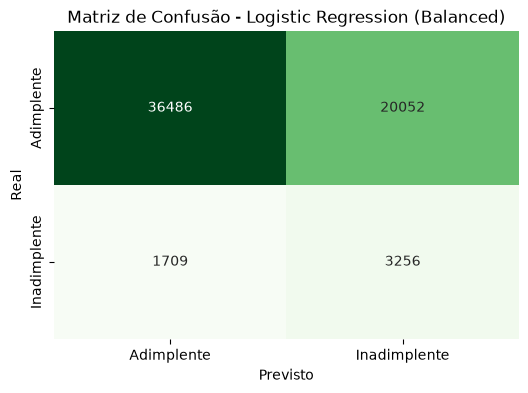

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_bal,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['Adimplente', 'Inadimplente'],
    yticklabels=['Adimplente', 'Inadimplente']
)

plt.title('Matriz de Confusão - Logistic Regression (Balanced)')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

## xgboost

In [108]:
import xgboost
print(xgboost.__version__)

3.3.0


In [109]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [110]:
y_pred_xgb = xgb_model.predict(X_test)

y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

In [111]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_xgb))

Accuracy : 0.919662455489976
Precision: 0.5789473684210527
Recall   : 0.01772406847935549
F1-Score : 0.03439515341020129
ROC-AUC  : 0.7527710511127861


In [112]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_xgb)

array([[56474,    64],
       [ 4877,    88]])

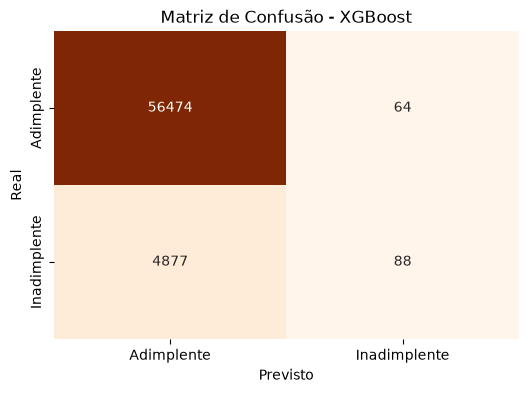

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    cbar=False,
    xticklabels=['Adimplente', 'Inadimplente'],
    yticklabels=['Adimplente', 'Inadimplente']
)

plt.title('Matriz de Confusão - XGBoost')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

In [114]:
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print(scale_pos_weight)

11.38710976837865


In [115]:
from xgboost import XGBClassifier

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [116]:
y_pred_xgb_bal = xgb_balanced.predict(X_test)

y_proba_xgb_bal = xgb_balanced.predict_proba(X_test)[:, 1]

In [117]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_bal))
print("Precision:", precision_score(y_test, y_pred_xgb_bal))
print("Recall   :", recall_score(y_test, y_pred_xgb_bal))
print("F1-Score :", f1_score(y_test, y_pred_xgb_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_xgb_bal))

Accuracy : 0.7048599255320879
Precision: 0.16545740524633415
Recall   : 0.656797583081571
F1-Score : 0.2643268217556943
ROC-AUC  : 0.7509355488062694


In [118]:
import joblib

joblib.dump(
    xgb_balanced,
    '../Model/artifacts/xgb_balanced_model.joblib'
)

['../Model/artifacts/xgb_balanced_model.joblib']

In [ ]:
import joblib

joblib.dump(
    X_encoded.columns.tolist(),
    "../Model/artifacts/features.joblib"
)

In [119]:

print(X_encoded.shape)
print(X_encoded.columns.tolist())


(307511, 119)
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Maternity leave', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Unemployed', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_S

In [120]:
print(X_encoded.shape)

(307511, 119)


In [121]:
print(X_encoded.columns.tolist())

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Maternity leave', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Unemployed', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not ma

In [122]:
import joblib

joblib.dump(
    X_encoded.columns.tolist(),
    "../Model/artifacts/features.joblib"
)

['../Model/artifacts/features.joblib']

In [123]:
import joblib

features = joblib.load("../Model/artifacts/features.joblib")

print(len(features))

119
